In [1]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train_features.csv")
test_df = pd.read_csv("../data/processed/test_features.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (226980, 31)
Test: (56746, 31)


In [2]:
X_train = train_df.drop(columns="Class")
y_train = train_df["Class"]

X_test = test_df.drop(columns="Class")
y_test = test_df["Class"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
y_train: (226980,)
X_test: (56746, 30)
y_test: (56746,)


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([
    ("scaler", StandardScaler())
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (226980, 30)
X_test_processed: (56746, 30)


In [4]:
print("Pipeline steps:")
print(preprocessor.named_steps)

print("\nFirst 5 feature means:")
print(X_train_processed.mean(axis=0)[:5])

print("\nFirst 5 feature stds:")
print(X_train_processed.std(axis=0)[:5])

Pipeline steps:
{'scaler': StandardScaler()}

First 5 feature means:
[ 1.85320865e-17  1.56521001e-17 -1.00173441e-17  5.75997283e-18
 -2.12868561e-17]

First 5 feature stds:
[1. 1. 1. 1. 1.]


In [5]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nScaler fitted on train only:")
print(preprocessor.named_steps["scaler"].mean_[:5])

Train shape: (226980, 30)
Test shape: (56746, 30)

Scaler fitted on train only:
[-1.49258426e-16  1.03929945e-17 -1.22712465e-17  5.75997283e-18
 -2.72972626e-17]


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

final_preprocessor = Pipeline([
    ("scaler", StandardScaler())
])

X_train_final = final_preprocessor.fit_transform(X_train)
X_test_final = final_preprocessor.transform(X_test)

print(X_train_final.shape)
print(X_test_final.shape)

(226980, 30)
(56746, 30)


In [7]:
print("Number of features:", X_train.shape[1])
print("Target distribution:")
print(y_train.value_counts())

Number of features: 30
Target distribution:
Class
0    226602
1       378
Name: count, dtype: int64


In [8]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)

mi_scores_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending=False)

print(mi_scores_df)


      Feature  MI_Score
17        V17  0.008013
14        V14  0.007946
10        V10  0.007320
12        V12  0.007315
11        V11  0.006577
16        V16  0.005876
3          V3  0.004671
4          V4  0.004623
9          V9  0.004051
18        V18  0.003992
7          V7  0.003814
2          V2  0.002962
27        V27  0.002239
21        V21  0.002167
6          V6  0.002074
5          V5  0.002060
1          V1  0.001981
28        V28  0.001651
8          V8  0.001626
29  LogAmount  0.001533
0        Time  0.001432
19        V19  0.001065
20        V20  0.000787
23        V23  0.000485
24        V24  0.000335
25        V25  0.000238
22        V22  0.000164
26        V26  0.000159
15        V15  0.000103
13        V13  0.000000


In [9]:
top_features = mi_scores_df.head(20)["Feature"].tolist()

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

print("Selected features:")
print(top_features)

print("\nTrain shape:", X_train_selected.shape)
print("Test shape:", X_test_selected.shape)

Selected features:
['V17', 'V14', 'V10', 'V12', 'V11', 'V16', 'V3', 'V4', 'V9', 'V18', 'V7', 'V2', 'V27', 'V21', 'V6', 'V5', 'V1', 'V28', 'V8', 'LogAmount']

Train shape: (226980, 20)
Test shape: (56746, 20)


In [10]:
missing_train = X_train_selected.isnull().sum().sum()
missing_test = X_test_selected.isnull().sum().sum()

print("Missing values - train:", missing_train)
print("Missing values - test:", missing_test)
print("Feature count:", len(top_features))

Missing values - train: 0
Missing values - test: 0
Feature count: 20


In [11]:
print("Final train:", X_train_final.shape)
print("Final test:", X_test_final.shape)

print("\nTarget train:")
print(y_train.value_counts())

print("\nTarget test:")
print(y_test.value_counts())

Final train: (226980, 30)
Final test: (56746, 30)

Target train:
Class
0    226602
1       378
Name: count, dtype: int64

Target test:
Class
0    56651
1       95
Name: count, dtype: int64


In [12]:
X_train_final = X_train_selected.copy()
X_test_final = X_test_selected.copy()

print("Final train:", X_train_final.shape)
print("Final test:", X_test_final.shape)

Final train: (226980, 20)
Final test: (56746, 20)


In [13]:
train_final_df = X_train_final.copy()
train_final_df["Class"] = y_train.values

test_final_df = X_test_final.copy()
test_final_df["Class"] = y_test.values

train_final_df.to_csv("../data/processed/train_final.csv", index=False)
test_final_df.to_csv("../data/processed/test_final.csv", index=False)

print(train_final_df.shape)
print(test_final_df.shape)

(226980, 21)
(56746, 21)


In [14]:
import os

print("Train file exists:", os.path.exists("../data/processed/train_final.csv"))
print("Test file exists:", os.path.exists("../data/processed/test_final.csv"))

Train file exists: True
Test file exists: True


In [15]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train_final.csv")
test_df = pd.read_csv("../data/processed/test_final.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (226980, 21)
Test: (56746, 21)


In [16]:
X_train = train_df.drop(columns="Class")
y_train = train_df["Class"]

X_test = test_df.drop(columns="Class")
y_test = test_df["Class"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

X_train: (226980, 20)
X_test: (56746, 20)
Fraud in train: 378
Fraud in test: 95


In [17]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


In [18]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

Predictions: (56746,)
Probabilities: (56746,)


In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

Confusion Matrix:
[[56642     9]
 [   40    55]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.93      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.95983830823816
PR-AUC: 0.6939847457998095


In [20]:
baseline_metrics = {
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob)
}

print(baseline_metrics)

{'ROC-AUC': 0.95983830823816, 'PR-AUC': 0.6939847457998095}


In [21]:
import joblib

joblib.dump(baseline_model, "../models/baseline_logistic_regression.pkl")

print("Baseline model saved.")

Baseline model saved.


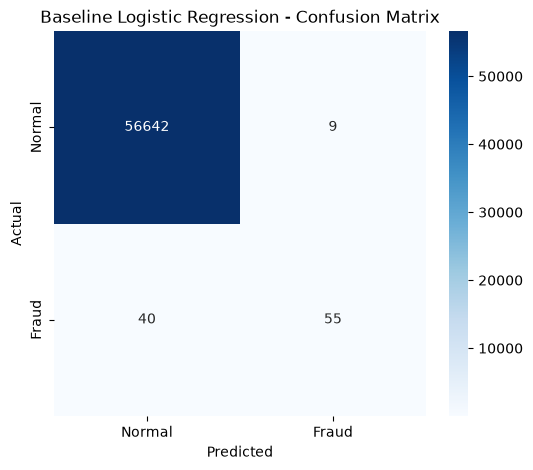

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

In [23]:
print("False Negatives:", cm[1, 0])
print("False Positives:", cm[0, 1])

False Negatives: 40
False Positives: 9


In [24]:
print("Class distribution:")
print(y_train.value_counts())

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

Class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Class proportions:
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64


In [25]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.5008340614822464), np.int64(1): np.float64(300.23809523809524)}


In [26]:
weighted_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

weighted_model.fit(X_train, y_train)

print("Class-weighted model trained.")

Class-weighted model trained.


In [27]:
y_pred_weighted = weighted_model.predict(X_test)
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_weighted))
print("PR-AUC:", average_precision_score(y_test, y_prob_weighted))

Confusion Matrix:
[[55402  1249]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.12        95

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC-AUC: 0.9675434725451959
PR-AUC: 0.6607074262143615


In [28]:
print("Baseline PR-AUC:", average_precision_score(y_test, y_prob))
print("Weighted PR-AUC:", average_precision_score(y_test, y_prob_weighted))

print("\nBaseline Recall:", classification_report(y_test, y_pred, output_dict=True)["1"]["recall"])
print("Weighted Recall:", classification_report(y_test, y_pred_weighted, output_dict=True)["1"]["recall"])

Baseline PR-AUC: 0.6939847457998095
Weighted PR-AUC: 0.6607074262143615

Baseline Recall: 0.5789473684210527
Weighted Recall: 0.8736842105263158


In [29]:
imbalance_results = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Class-Weighted Logistic Regression"],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, y_prob_weighted)
    ],
    "Recall": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_weighted, output_dict=True)["1"]["recall"]
    ]
})

print(imbalance_results)

                                Model    PR-AUC    Recall
0        Baseline Logistic Regression  0.693985  0.578947
1  Class-Weighted Logistic Regression  0.660707  0.873684


In [30]:
joblib.dump(
    weighted_model,
    "../models/class_weighted_logistic_regression.pkl"
)

print("Class-weighted model saved.")

Class-weighted model saved.


In [31]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

print("Number of thresholds:", len(thresholds))
print("Precision values:", len(precision))
print("Recall values:", len(recall))

Number of thresholds: 56098
Precision values: 56099
Recall values: 56099


In [32]:
target_recall = 0.80

valid_indices = np.where(recall[:-1] >= target_recall)[0]

idx = valid_indices[-1]
selected_threshold = thresholds[idx]

print("Selected threshold:", selected_threshold)
print("Precision:", precision[idx])
print("Recall:", recall[idx])

Selected threshold: 0.023479293020586225
Precision: 0.7307692307692307
Recall: 0.8


In [33]:
y_pred_threshold = (y_prob >= selected_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_threshold))
print()
print(classification_report(y_test, y_pred_threshold))

[[56623    28]
 [   19    76]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.80      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.90      0.88     56746
weighted avg       1.00      1.00      1.00     56746



In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_precision = precision_score(y_test, y_pred_threshold)
threshold_recall = recall_score(y_test, y_pred_threshold)
threshold_f1 = f1_score(y_test, y_pred_threshold)

print("Threshold:", selected_threshold)
print("Precision:", threshold_precision)
print("Recall:", threshold_recall)
print("F1-score:", threshold_f1)

Threshold: 0.023479293020586225
Precision: 0.7307692307692307
Recall: 0.8
F1-score: 0.7638190954773869


In [35]:
threshold_results = {
    "threshold": selected_threshold,
    "precision": threshold_precision,
    "recall": threshold_recall,
    "f1_score": threshold_f1
}

print(threshold_results)

{'threshold': np.float64(0.023479293020586225), 'precision': 0.7307692307692307, 'recall': 0.8, 'f1_score': 0.7638190954773869}


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained.")


Random Forest trained.


In [37]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Confusion Matrix:
[[56649     2]
 [   25    70]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9296656629836051
PR-AUC: 0.8012111150240065


In [38]:
rf_metrics = {
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "PR-AUC": average_precision_score(y_test, y_prob_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf)
}

print(rf_metrics)

{'ROC-AUC': 0.9296656629836051, 'PR-AUC': 0.8012111150240065, 'Precision': 0.9722222222222222, 'Recall': 0.7368421052631579, 'F1': 0.8383233532934131}


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

      Feature  Importance
0         V17    0.200602
3         V12    0.141683
1         V14    0.121636
2         V10    0.086915
5         V16    0.086762
4         V11    0.052274
8          V9    0.040685
10         V7    0.032770
7          V4    0.030324
6          V3    0.026449
13        V21    0.021716
9         V18    0.021505
16         V1    0.020739
14         V6    0.019373
12        V27    0.018846
18         V8    0.016888
15         V5    0.016199
19  LogAmount    0.015137
17        V28    0.014917
11         V2    0.014580


In [40]:
print("Top 10 features:")
print(feature_importance.head(10))

Top 10 features:
   Feature  Importance
0      V17    0.200602
3      V12    0.141683
1      V14    0.121636
2      V10    0.086915
5      V16    0.086762
4      V11    0.052274
8       V9    0.040685
10      V7    0.032770
7       V4    0.030324
6       V3    0.026449


In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained.")

Gradient Boosting trained.


In [56]:
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_metrics = {
    "ROC-AUC": roc_auc_score(y_test, gb_prob),
    "PR-AUC": average_precision_score(y_test, gb_prob),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1": f1_score(y_test, gb_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))

print("\nGradient Boosting Metrics:")
for metric, value in gb_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56639    12]
 [   48    47]]

Gradient Boosting Metrics:
ROC-AUC: 0.6682
PR-AUC: 0.4312
Precision: 0.7966
Recall: 0.4947
F1: 0.6104


In [57]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained.")

XGBoost trained.


In [58]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    "ROC-AUC": roc_auc_score(y_test, xgb_prob),
    "PR-AUC": average_precision_score(y_test, xgb_prob),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1": f1_score(y_test, xgb_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nXGBoost Metrics:")
for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56648     3]
 [   27    68]]

XGBoost Metrics:
ROC-AUC: 0.9806
PR-AUC: 0.7848
Precision: 0.9577
Recall: 0.7158
F1: 0.8193


In [45]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train)

print("LightGBM trained.")

LightGBM trained.


In [46]:
lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_metrics = {
    "ROC-AUC": roc_auc_score(y_test, lgbm_prob),
    "PR-AUC": average_precision_score(y_test, lgbm_prob),
    "Precision": precision_score(y_test, lgbm_pred),
    "Recall": recall_score(y_test, lgbm_pred),
    "F1": f1_score(y_test, lgbm_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, lgbm_pred))

print("\nLightGBM Metrics:")
for metric, value in lgbm_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56613    38]
 [   43    52]]

LightGBM Metrics:
ROC-AUC: 0.7725
PR-AUC: 0.3242
Precision: 0.5778
Recall: 0.5474
F1: 0.5622


In [47]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

print("CatBoost trained.")

CatBoost trained.


In [48]:
cat_pred = cat_model.predict(X_test).ravel()
cat_prob = cat_model.predict_proba(X_test)[:, 1]

cat_metrics = {
    "ROC-AUC": roc_auc_score(y_test, cat_prob),
    "PR-AUC": average_precision_score(y_test, cat_prob),
    "Precision": precision_score(y_test, cat_pred),
    "Recall": recall_score(y_test, cat_pred),
    "F1": f1_score(y_test, cat_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, cat_pred))

print("\nCatBoost Metrics:")
for metric, value in cat_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56648     3]
 [   26    69]]

CatBoost Metrics:
ROC-AUC: 0.9787
PR-AUC: 0.8166
Precision: 0.9583
Recall: 0.7263
F1: 0.8263


In [49]:
weighted_metrics = {
    "ROC-AUC": roc_auc_score(y_test, weighted_model.predict_proba(X_test)[:, 1]),
    "PR-AUC": average_precision_score(y_test, weighted_model.predict_proba(X_test)[:, 1]),
    "Precision": precision_score(y_test, weighted_model.predict(X_test)),
    "Recall": recall_score(y_test, weighted_model.predict(X_test)),
    "F1": f1_score(y_test, weighted_model.predict(X_test))
}

print(weighted_metrics)

{'ROC-AUC': 0.9675434725451959, 'PR-AUC': 0.6607074262143615, 'Precision': 0.06231231231231231, 'Recall': 0.8736842105263158, 'F1': 0.11632796075683252}


In [50]:
model_comparison = pd.DataFrame({
    "Logistic Regression": baseline_metrics,
    "Weighted Logistic": weighted_metrics,
    "Random Forest": rf_metrics,
    "Gradient Boosting": gb_metrics,
    "XGBoost": xgb_metrics,
    "LightGBM": lgbm_metrics,
    "CatBoost": cat_metrics
}).T

print(model_comparison.round(4))

                     ROC-AUC  PR-AUC  Precision  Recall      F1
Logistic Regression   0.9598  0.6940        NaN     NaN     NaN
Weighted Logistic     0.9675  0.6607     0.0623  0.8737  0.1163
Random Forest         0.9297  0.8012     0.9722  0.7368  0.8383
Gradient Boosting     0.6682  0.4312     0.7966  0.4947  0.6104
XGBoost               0.9806  0.7848     0.9577  0.7158  0.8193
LightGBM              0.7725  0.3242     0.5778  0.5474  0.5622
CatBoost              0.9787  0.8166     0.9583  0.7263  0.8263


In [51]:
baseline_metrics = {
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

print(baseline_metrics)

{'ROC-AUC': 0.95983830823816, 'PR-AUC': 0.6939847457998095, 'Precision': 0.859375, 'Recall': 0.5789473684210527, 'F1': 0.6918238993710691}


In [52]:
model_comparison = pd.DataFrame({
    "Logistic Regression": baseline_metrics,
    "Weighted Logistic": weighted_metrics,
    "Random Forest": rf_metrics,
    "Gradient Boosting": gb_metrics,
    "XGBoost": xgb_metrics,
    "LightGBM": lgbm_metrics,
    "CatBoost": cat_metrics
}).T

print(model_comparison.round(4))

                     ROC-AUC  PR-AUC  Precision  Recall      F1
Logistic Regression   0.9598  0.6940     0.8594  0.5789  0.6918
Weighted Logistic     0.9675  0.6607     0.0623  0.8737  0.1163
Random Forest         0.9297  0.8012     0.9722  0.7368  0.8383
Gradient Boosting     0.6682  0.4312     0.7966  0.4947  0.6104
XGBoost               0.9806  0.7848     0.9577  0.7158  0.8193
LightGBM              0.7725  0.3242     0.5778  0.5474  0.5622
CatBoost              0.9787  0.8166     0.9583  0.7263  0.8263


In [53]:
model_comparison.to_csv("../data/processed/model_comparison.csv")

print("Model comparison saved.")

Model comparison saved.


In [54]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="average_precision",
    n_jobs=-1
)

print("XGBoost 5-Fold PR-AUC:")
print(xgb_cv_scores)
print("Mean PR-AUC:", xgb_cv_scores.mean())
print("Std PR-AUC:", xgb_cv_scores.std())

XGBoost 5-Fold PR-AUC:
[0.77278145 0.83836536 0.79513392 0.84964352 0.86302304]
Mean PR-AUC: 0.8237894591770569
Std PR-AUC: 0.03418514330142403


In [55]:
cat_cv_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=skf,
    scoring="average_precision",
    n_jobs=-1
)

print("CatBoost 5-Fold PR-AUC:")
print(cat_cv_scores)
print("Mean PR-AUC:", cat_cv_scores.mean())
print("Std PR-AUC:", cat_cv_scores.std())

CatBoost 5-Fold PR-AUC:
[0.83853372 0.8711997  0.79279242 0.87259133 0.8835961 ]
Mean PR-AUC: 0.8517426552264308
Std PR-AUC: 0.033098312919921054


In [59]:
cat_cv_scores = cross_val_score(
    cat_model,
    X_train,
    y_train,
    cv=skf,
    scoring="average_precision",
    n_jobs=-1
)

print("CatBoost 5-Fold PR-AUC:")
print(cat_cv_scores)
print("Mean PR-AUC:", cat_cv_scores.mean())
print("Std PR-AUC:", cat_cv_scores.std())

CatBoost 5-Fold PR-AUC:
[0.83853372 0.8711997  0.79279242 0.87259133 0.8835961 ]
Mean PR-AUC: 0.8517426552264308
Std PR-AUC: 0.033098312919921054


In [60]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=skf,
    scoring="average_precision",
    n_jobs=-1
)

print("Random Forest 5-Fold PR-AUC:")
print(rf_cv_scores)
print("Mean PR-AUC:", rf_cv_scores.mean())
print("Std PR-AUC:", rf_cv_scores.std())


Random Forest 5-Fold PR-AUC:
[0.82971965 0.86075751 0.77596643 0.87408829 0.85747008]
Mean PR-AUC: 0.8396003925349452
Std PR-AUC: 0.03493787276059043


In [61]:
cv_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "Mean_PR_AUC": [
        rf_cv_scores.mean(),
        xgb_cv_scores.mean(),
        cat_cv_scores.mean()
    ],
    "Std_PR_AUC": [
        rf_cv_scores.std(),
        xgb_cv_scores.std(),
        cat_cv_scores.std()
    ]
})

print(cv_results)

cv_results.to_csv("../data/processed/cross_validation_results.csv", index=False)

print("\nCV results saved.")

           Model  Mean_PR_AUC  Std_PR_AUC
0  Random Forest     0.839600    0.034938
1        XGBoost     0.823789    0.034185
2       CatBoost     0.851743    0.033098

CV results saved.


In [62]:
import joblib

joblib.dump(rf_model, "../models/random_forest.pkl")
joblib.dump(xgb_model, "../models/xgboost.pkl")
joblib.dump(cat_model, "../models/catboost.pkl")

print("Ensemble models saved.")

Ensemble models saved.


In [63]:
from sklearn.model_selection import RandomizedSearchCV

cat_param_grid = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        random_seed=42,
        verbose=0
    ),
    param_distributions=cat_param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("Best parameters:")
print(cat_search.best_params_)

print("\nBest CV PR-AUC:")
print(cat_search.best_score_)

Best parameters:
{'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 100, 'depth': 8}

Best CV PR-AUC:
0.8529884808673938


In [64]:
best_cat_model = cat_search.best_estimator_

best_cat_model.fit(X_train, y_train)

print("Tuned CatBoost trained.")

Tuned CatBoost trained.


In [65]:
tuned_cat_pred = best_cat_model.predict(X_test).ravel()
tuned_cat_prob = best_cat_model.predict_proba(X_test)[:, 1]

tuned_cat_metrics = {
    "ROC-AUC": roc_auc_score(y_test, tuned_cat_prob),
    "PR-AUC": average_precision_score(y_test, tuned_cat_prob),
    "Precision": precision_score(y_test, tuned_cat_pred),
    "Recall": recall_score(y_test, tuned_cat_pred),
    "F1": f1_score(y_test, tuned_cat_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_cat_pred))

print("\nTuned CatBoost Metrics:")
for metric, value in tuned_cat_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56649     2]
 [   25    70]]

Tuned CatBoost Metrics:
ROC-AUC: 0.9828
PR-AUC: 0.8317
Precision: 0.9722
Recall: 0.7368
F1: 0.8383


In [66]:
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest CV PR-AUC:")
print(xgb_search.best_score_)

Best parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV PR-AUC:
0.8483460902991578


In [67]:
best_xgb_model = xgb_search.best_estimator_

best_xgb_model.fit(X_train, y_train)

print("Tuned XGBoost trained.")

Tuned XGBoost trained.


In [68]:
tuned_xgb_pred = best_xgb_model.predict(X_test)
tuned_xgb_prob = best_xgb_model.predict_proba(X_test)[:, 1]

tuned_xgb_metrics = {
    "ROC-AUC": roc_auc_score(y_test, tuned_xgb_prob),
    "PR-AUC": average_precision_score(y_test, tuned_xgb_prob),
    "Precision": precision_score(y_test, tuned_xgb_pred),
    "Recall": recall_score(y_test, tuned_xgb_pred),
    "F1": f1_score(y_test, tuned_xgb_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_xgb_pred))

print("\nTuned XGBoost Metrics:")
for metric, value in tuned_xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56649     2]
 [   25    70]]

Tuned XGBoost Metrics:
ROC-AUC: 0.9835
PR-AUC: 0.8207
Precision: 0.9722
Recall: 0.7368
F1: 0.8383


In [70]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest CV PR-AUC:")
print(rf_search.best_score_)

Best parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}

Best CV PR-AUC:
0.8423178700219358


In [71]:
best_rf_model = rf_search.best_estimator_

best_rf_model.fit(X_train, y_train)

print("Tuned Random Forest trained.")

Tuned Random Forest trained.


In [72]:
tuned_rf_pred = best_rf_model.predict(X_test)
tuned_rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

tuned_rf_metrics = {
    "ROC-AUC": roc_auc_score(y_test, tuned_rf_prob),
    "PR-AUC": average_precision_score(y_test, tuned_rf_prob),
    "Precision": precision_score(y_test, tuned_rf_pred),
    "Recall": recall_score(y_test, tuned_rf_pred),
    "F1": f1_score(y_test, tuned_rf_pred)
}

print("Confusion Matrix:")
print(confusion_matrix(y_test, tuned_rf_pred))

print("\nTuned Random Forest Metrics:")
for metric, value in tuned_rf_metrics.items():
    print(f"{metric}: {value:.4f}")

Confusion Matrix:
[[56649     2]
 [   26    69]]

Tuned Random Forest Metrics:
ROC-AUC: 0.9660
PR-AUC: 0.7928
Precision: 0.9718
Recall: 0.7263
F1: 0.8313


In [73]:
tuned_comparison = pd.DataFrame({
    "Tuned Random Forest": tuned_rf_metrics,
    "Tuned XGBoost": tuned_xgb_metrics,
    "Tuned CatBoost": tuned_cat_metrics
}).T

print(tuned_comparison.round(4))

                     ROC-AUC  PR-AUC  Precision  Recall      F1
Tuned Random Forest   0.9660  0.7928     0.9718  0.7263  0.8313
Tuned XGBoost         0.9835  0.8207     0.9722  0.7368  0.8383
Tuned CatBoost        0.9828  0.8317     0.9722  0.7368  0.8383


In [74]:
tuned_comparison.to_csv(
    "../data/processed/tuned_model_comparison.csv"
)

print("Tuned model comparison saved.")

Tuned model comparison saved.


In [75]:
joblib.dump(best_rf_model, "../models/tuned_random_forest.pkl")
joblib.dump(best_xgb_model, "../models/tuned_xgboost.pkl")
joblib.dump(best_cat_model, "../models/tuned_catboost.pkl")

print("Tuned models saved.")

Tuned models saved.
